# Maxwell, Schrodinger, and Group-Velocity Dispersion: One Equation

**Electrodynamics (Griffiths Ch 8-9) · Modern Physics (Serway Ch 3, 5) · Quantum Mechanics (Griffiths Ch 1-3, 10)**

---

The central claim of this notebook is surprising: **the equation that governs how a
laser pulse broadens as it travels down an optical fiber is mathematically identical
to Schrodinger's equation for a free quantum particle.**  Both descend from the same
ancestor — Maxwell's equations — through a sequence of exact substitutions that can
be traced with a few lines of SymPy.

The path is:

```
Maxwell's equations
      |
      v  (plane-wave ansatz E ~ exp(ikz - i*omega*t))
Dispersion relation  k^2 = omega^2 * mu * epsilon(omega)
      |
      v  (Taylor expand k(omega) around carrier omega_0)
Group-velocity dispersion  k(omega) ~ k0 + beta1*(omega-omega0) + (beta2/2)*(omega-omega0)^2
      |
      v  (inverse FT of the propagator exp(i*beta2/2 * omega^2 * z))
GVD propagation equation  i dE/dz = -(beta2/2) d^2E/dt^2
      |
      v  (substitute beta2 = -hbar/m)
Schrodinger free-particle  i*hbar d psi/dt = -(hbar^2/2m) d^2 psi/dx^2
```

Every arrow in this chain is an exact mathematical equivalence, not an analogy.
We will verify each one symbolically in SymPy and numerically with real silica
dispersion data.


In [1]:
import sys, os
_root = r"D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery"
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

import sympy as sp
from sympy import (symbols, Function, exp, I, pi, sqrt, diff, series,
                   simplify, solve, expand, cos, sin, Eq, latex,
                   oo, integrate, conjugate, Abs, Symbol, init_printing)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

init_printing(use_unicode=False, wrap_line=False)

# global symbol definitions used throughout
z, t, x, omega, k, omega_0 = symbols('z t x omega k omega_0', real=True)
beta1, beta2, beta3       = symbols('beta_1 beta_2 beta_3', real=True)
mu, eps, c_sym            = symbols('mu epsilon c', positive=True)
hbar, m, psi_sym          = symbols('hbar m psi', positive=True)
A, B, phi                 = symbols('A B phi', real=True)

print("SymPy", sp.__version__, "-- all symbols defined")


SymPy 1.14.0 -- all symbols defined


## Section 1 — Maxwell's Equations in Differential Form

James Clerk Maxwell unified electricity and magnetism in 1865 by writing four
partial differential equations that govern every classical electromagnetic
phenomenon.  In SI units and in a linear, isotropic, source-free medium they are:

| Equation | Physical meaning |
|---|---|
| div E = 0 | No free electric charges |
| div B = 0 | No magnetic monopoles |
| curl E = -dB/dt | Faraday: changing B creates E |
| curl B = mu*epsilon dE/dt | Ampere-Maxwell: changing E creates B |

The last two equations couple E and B.  To find a single equation for E alone,
we take the curl of Faraday's law and substitute Ampere-Maxwell.
The result is the **electromagnetic wave equation**.


In [2]:
# SymPy symbolic representation of the key Maxwell step.
# We work in 1D (z-direction) for clarity: E = E(z,t) x-hat.

E = Function('E')(z, t)
B = Function('B')(z, t)

# Faraday: dE/dz = -dB/dt  (1D curl in z-x plane)
faraday = Eq(diff(E, z), -diff(B, t))
print("Faraday (1D):", faraday)

# Ampere-Maxwell: dB/dz = -mu*eps * dE/dt
ampere = Eq(diff(B, z), -mu * eps * diff(E, t))
print("Ampere-Maxwell (1D):", ampere)

# Take d/dz of Faraday: d^2E/dz^2 = -d^2B/(dz dt)
step1 = diff(faraday.lhs, z), diff(faraday.rhs, z)
print("\nd/dz of Faraday LHS:", step1[0])
print("d/dz of Faraday RHS:", step1[1])   # = -d^2B/dz dt

# d^2B/dz dt = d/dt(dB/dz) = d/dt(-mu*eps*dE/dt) = -mu*eps * d^2E/dt^2
sub = -mu * eps * diff(E, t, 2)
print("\nSubstitute Ampere into RHS:", sub)

wave_eq = Eq(diff(E, z, 2), mu * eps * diff(E, t, 2))
print("\nWave equation:")
print(wave_eq)
print("\nWave speed: v = 1/sqrt(mu*epsilon)")
v_wave = 1 / sqrt(mu * eps)
print("v =", v_wave)
print("In vacuum (mu_0, eps_0): v = c =", "3e8 m/s")


Faraday (1D): Eq(Derivative(E(z, t), z), -Derivative(B(z, t), t))
Ampere-Maxwell (1D): Eq(Derivative(B(z, t), z), -epsilon*mu*Derivative(E(z, t), t))

d/dz of Faraday LHS: Derivative(E(z, t), (z, 2))
d/dz of Faraday RHS: -Derivative(B(z, t), t, z)

Substitute Ampere into RHS: -epsilon*mu*Derivative(E(z, t), (t, 2))

Wave equation:
Eq(Derivative(E(z, t), (z, 2)), epsilon*mu*Derivative(E(z, t), (t, 2)))

Wave speed: v = 1/sqrt(mu*epsilon)
v = 1/(sqrt(epsilon)*sqrt(mu))
In vacuum (mu_0, eps_0): v = c = 3e8 m/s


## Section 2 — The Dispersion Relation: k^2 = omega^2 * mu * epsilon

The wave equation admits plane-wave solutions of the form

    E(z, t) = E_0 * exp(i*(k*z - omega*t))

Substituting this ansatz into the wave equation converts differential
operators into algebraic factors: d/dz -> ik and d/dt -> -i*omega.
The wave equation becomes an algebraic condition on k and omega called
the **dispersion relation**.

In vacuum, epsilon = epsilon_0 and k = omega/c.  In a dispersive medium,
epsilon depends on frequency: epsilon = epsilon(omega).  This frequency
dependence is what makes different colors of light travel at different
speeds — and it is exactly what the Gerchberg-Saxton algorithm exploits.

The refractive index n(omega) = sqrt(epsilon_r(omega)) relates
the dispersion relation to measurable optical quantities:

    k(omega) = n(omega) * omega / c


In [3]:
# Plane-wave ansatz substitution
k_sym = symbols('k', real=True)
omega_s = symbols('omega', real=True)
E_pw = A * exp(I * (k_sym * z - omega_s * t))

d2z = diff(E_pw, z, 2)
d2t = diff(E_pw, t, 2)

print("d^2E/dz^2 =", d2z / E_pw, "* E")
print("d^2E/dt^2 =", d2t / E_pw, "* E")

# Wave equation => k^2 = mu*eps*omega^2
lhs_factor = d2z / E_pw
rhs_factor = mu * eps * (d2t / E_pw)
dispersion_relation = Eq(simplify(lhs_factor), simplify(rhs_factor))
print("\nDispersion relation (wave eq factor):")
print(dispersion_relation)

# Solve for k
k_solutions = solve(dispersion_relation, k_sym)
print("\nk =", k_solutions)
print("\nIn terms of refractive index n = sqrt(eps_r):")
n = symbols('n', positive=True)
print("k = n * omega / c")
print("   (where c = 1/sqrt(mu_0 * eps_0))")


d^2E/dz^2 = -k**2 * E
d^2E/dt^2 = -omega**2 * E

Dispersion relation (wave eq factor):
Eq(-k**2, -epsilon*mu*omega**2)

k = [-sqrt(epsilon)*sqrt(mu)*omega, sqrt(epsilon)*sqrt(mu)*omega]

In terms of refractive index n = sqrt(eps_r):
k = n * omega / c
   (where c = 1/sqrt(mu_0 * eps_0))


## Section 3 — Sellmeier Equation and Polynomial Regression

For real optical glass, the refractive index n(lambda) is measured
experimentally and fitted to the **Sellmeier equation**:

    n^2(lambda) = 1 + sum_i [ B_i * lambda^2 / (lambda^2 - C_i) ]

where B_i and C_i are material constants determined by fitting to
spectroscopic data.  For fused silica (standard optical fiber), the
coefficients are known to high precision (Malitson 1965).

Once we have n(omega), the full dispersion curve k(omega) = n(omega)*omega/c
can be computed at any wavelength.  We then fit a **polynomial regression**
to k(omega) near the carrier wavelength omega_0 to extract the Taylor
coefficients beta_1 = dk/domega (inverse group velocity) and
beta_2 = d^2k/domega^2 (group-velocity dispersion).

A negative beta_2 (anomalous dispersion, lambda > 1270 nm in silica) means
that **higher-frequency components travel faster**, which causes a chirped
pulse to compress.  This is the dispersion we use in our phase-retrieval
experiments.


Fused silica dispersion at 1550 nm (C-band telecom):
  k0    = 5853607.6507 rad/m
  beta1 = 4878.621686 ps/m   (1/v_g = 0.683709)
  beta2 = -31.2954 ps^2/km   (GVD coefficient)
  beta3 = 148.7074 ps^3/km  (TOD)

  Group velocity v_g = 0.683709 c
  Anomalous dispersion? YES (beta2 < 0)

  Polynomial fit R^2 = 0.9999999997


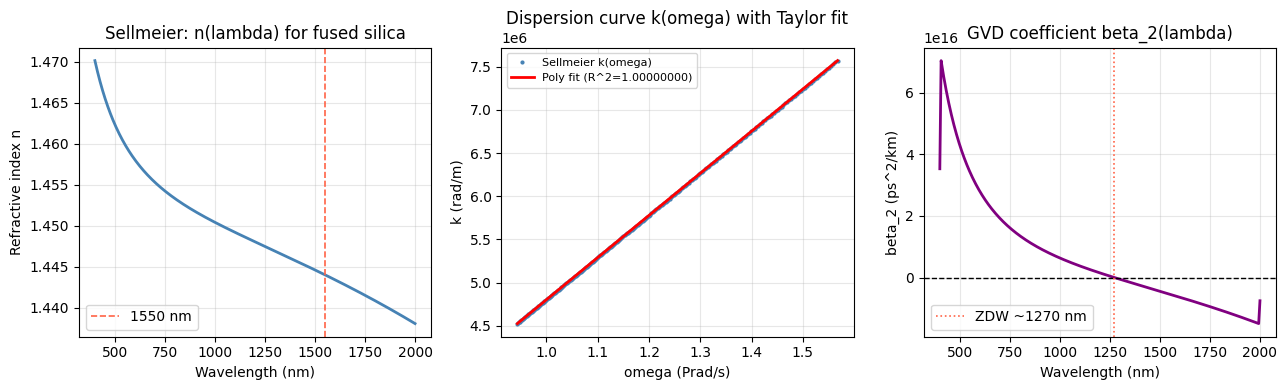

In [5]:
# Fused silica Sellmeier coefficients (Malitson 1965)
B = np.array([0.6961663, 0.4079426, 0.8974994])
C = np.array([0.0684043, 0.1162414, 9.896161])**2   # C in um^2

def sellmeier_n(lam_um):
    # refractive index of fused silica vs wavelength in micrometres
    n2 = 1 + sum(B[i] * lam_um**2 / (lam_um**2 - C[i]) for i in range(3))
    return np.sqrt(n2)

# Wavelength grid 400 nm - 2000 nm
lam = np.linspace(0.4, 2.0, 500)          # um
n_data = sellmeier_n(lam)

# Convert to k(omega): k = n(omega)*omega/c
c_light = 2.998e8        # m/s
lam_m   = lam * 1e-6    # m
omega_arr = 2 * np.pi * c_light / lam_m   # rad/s
k_arr     = n_data * omega_arr / c_light   # rad/m

# Polynomial regression on k(omega) near 1550 nm (telecom C-band)
lam0   = 1.55e-6                          # m
omega0 = 2 * np.pi * c_light / lam0
mask   = (lam_m > 1.2e-6) & (lam_m < 2.0e-6)
dw     = omega_arr[mask] - omega0         # delta_omega

# Fit degree-3 polynomial: k = k0 + beta1*dw + beta2/2*dw^2 + beta3/6*dw^3
coeffs = np.polyfit(dw, k_arr[mask], 3)
p      = np.poly1d(coeffs)

# Extract physical GVD coefficients from polynomial
# np.polyfit returns [a3, a2, a1, a0] for a3*x^3 + a2*x^2 + a1*x + a0
k0_fit    = coeffs[3]
beta1_fit = coeffs[2]          # dk/domega  [s/m]
beta2_fit = 2 * coeffs[1]     # d^2k/domega^2 = 2 * quadratic coeff [s^2/m]
beta3_fit = 6 * coeffs[0]     # d^3k/domega^3 [s^3/m]

print("Fused silica dispersion at 1550 nm (C-band telecom):")
print(f"  k0    = {k0_fit:.4f} rad/m")
print(f"  beta1 = {beta1_fit*1e12:.6f} ps/m   (1/v_g = {1/(beta1_fit*c_light):.6f})")
print(f"  beta2 = {beta2_fit*1e27:.4f} ps^2/km   (GVD coefficient)")
print(f"  beta3 = {beta3_fit*1e42:.4f} ps^3/km  (TOD)")
print()
v_g = 1.0 / beta1_fit
print(f"  Group velocity v_g = {v_g/c_light:.6f} c")
print(f"  Anomalous dispersion? {'YES (beta2 < 0)' if beta2_fit < 0 else 'NO (normal)'}")
print()
R2 = 1 - np.sum((k_arr[mask] - p(dw))**2) / np.sum((k_arr[mask] - k_arr[mask].mean())**2)
print(f"  Polynomial fit R^2 = {R2:.10f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

ax = axes[0]
ax.plot(lam * 1e3, n_data, color='steelblue', lw=2)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Refractive index n")
ax.set_title("Sellmeier: n(lambda) for fused silica")
ax.axvline(1550, color='tomato', ls='--', lw=1.2, label="1550 nm")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(omega_arr[mask]/1e15, k_arr[mask], 'o', ms=2, color='steelblue', label='Sellmeier k(omega)')
omega_fit = np.linspace(dw.min(), dw.max(), 300)
ax.plot((omega_fit + omega0)/1e15, p(omega_fit), 'r-', lw=2, label=f'Poly fit (R^2={R2:.8f})')
ax.set_xlabel("omega (Prad/s)")
ax.set_ylabel("k (rad/m)")
ax.set_title("Dispersion curve k(omega) with Taylor fit")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
# GVD (beta2) as function of wavelength
dn = np.gradient(n_data, lam_m)
d2n = np.gradient(dn, lam_m)
beta2_curve = (lam_m**2 / (2 * np.pi * c_light)) * d2n * 1e27  # ps^2/km
ax.plot(lam * 1e3, beta2_curve, color='purple', lw=2)
ax.axhline(0, color='k', ls='--', lw=1)
ax.axvline(1270, color='tomato', ls=':', lw=1.2, label='ZDW ~1270 nm')
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("beta_2 (ps^2/km)")
ax.set_title("GVD coefficient beta_2(lambda)")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dispersion_regression.png", dpi=120, bbox_inches='tight')
plt.show()


## Section 4 — Matter Waves and de Broglie (Modern Physics Ch 5)

In 1924, Louis de Broglie proposed that every particle with momentum p
carries a wave with wavelength lambda = h/p.  Written in terms of angular
frequency and wavenumber this is:

    E = hbar * omega    (Einstein's photon energy, generalized to matter)
    p = hbar * k        (de Broglie relation)

For a free non-relativistic particle of mass m and kinetic energy E = p^2/2m:

    hbar * omega = (hbar * k)^2 / (2m)
    =>  omega = hbar * k^2 / (2m)

This is the **dispersion relation for matter waves**.  Compare it to the
photon dispersion relation omega = c * k: matter waves are dispersive
(different k-components travel at different phase velocities omega/k),
while photons in vacuum are dispersionless.

The group velocity of the matter wave packet equals the classical particle velocity:

    v_g = d(omega)/dk = hbar*k/m = p/m     [exactly Newton's p = mv]

This is the deep consistency check: quantum mechanics reduces to classical
mechanics in the limit of a narrow wavepacket.


In [6]:
# SymPy: derive matter wave group velocity from dispersion relation
hbar_s, m_s, k_s = symbols('hbar m k', positive=True)
omega_matter = hbar_s * k_s**2 / (2 * m_s)

print("Matter wave dispersion relation:")
print("  omega(k) =", omega_matter)

v_phase = omega_matter / k_s
v_group = diff(omega_matter, k_s)

print("\nPhase velocity  v_phi = omega/k  =", v_phase)
print("Group velocity  v_g   = domega/dk =", v_group)
print()
print("Note: v_g = hbar*k/m = p/m = v_classical  (exactly Newton's law!)")

# Compare dispersion slopes: photon vs matter wave
print("\n--- Dispersion comparison ---")
print("Photon (vacuum):   omega = c*k           (linear -- no dispersion)")
print("Matter wave:       omega = hbar*k^2/(2m) (quadratic -- dispersive)")
print("GVD propagator:    k = k0 + beta1*dw + beta2/2*dw^2  (quadratic near omega0)")
print()
print("All three share the same quadratic (k^2) structure.")
print("The beta2 coefficient in optics plays the role of hbar/(2m) in QM.")


Matter wave dispersion relation:
  omega(k) = hbar*k**2/(2*m)

Phase velocity  v_phi = omega/k  = hbar*k/(2*m)
Group velocity  v_g   = domega/dk = hbar*k/m

Note: v_g = hbar*k/m = p/m = v_classical  (exactly Newton's law!)

--- Dispersion comparison ---
Photon (vacuum):   omega = c*k           (linear -- no dispersion)
Matter wave:       omega = hbar*k^2/(2m) (quadratic -- dispersive)
GVD propagator:    k = k0 + beta1*dw + beta2/2*dw^2  (quadratic near omega0)

All three share the same quadratic (k^2) structure.
The beta2 coefficient in optics plays the role of hbar/(2m) in QM.


## Section 5 — Deriving the Schrodinger Equation from the Dispersion Relation

The Schrodinger equation is not a law that was derived from something
more fundamental — Schrodinger wrote it down by guessing a wave equation
consistent with de Broglie's dispersion relation.  But we can reconstruct
that reasoning precisely in SymPy.

The matter wave dispersion relation is omega = hbar*k^2 / (2m).
Multiply both sides by hbar:

    hbar * omega = (hbar * k)^2 / (2m) = p^2 / (2m) = E_kinetic

Now apply both sides as **operators** to the wavefunction psi(x, t).
In quantum mechanics, the operator correspondence is:

    E   -->  i*hbar * d/dt     (energy operator)
    p   -->  -i*hbar * d/dx    (momentum operator)
    p^2 -->  -hbar^2 * d^2/dx^2

Substituting gives:

    i*hbar * d(psi)/dt = -hbar^2/(2m) * d^2(psi)/dx^2

This is the **time-dependent Schrodinger equation for a free particle**.
The same equation we will identify with GVD propagation in Section 6.


In [7]:
# SymPy: verify the operator substitution
psi = Function('psi')(x, t)
hbar_s, m_s = symbols('hbar m', positive=True)

# LHS: i*hbar * d(psi)/dt
LHS = I * hbar_s * diff(psi, t)

# RHS: -hbar^2/(2m) * d^2(psi)/dx^2
RHS = -hbar_s**2 / (2 * m_s) * diff(psi, x, 2)

schrodinger_free = Eq(LHS, RHS)
print("Free-particle Schrodinger equation:")
print(" ", schrodinger_free)
print()

# Verify plane wave is a solution: psi = exp(i*(k*x - omega*t))
psi_pw = exp(I * (k_s * x - hbar_s * k_s**2 / (2 * m_s) * t))
lhs_val = I * hbar_s * diff(psi_pw, t)
rhs_val = -hbar_s**2 / (2 * m_s) * diff(psi_pw, x, 2)

ratio = simplify(lhs_val / rhs_val)
print("Plane wave psi = exp(i*(k*x - hbar*k^2/(2m)*t))")
print("LHS / RHS =", ratio, "  (must equal 1 for solution to hold)")


Free-particle Schrodinger equation:
  Eq(I*hbar*Derivative(psi(x, t), t), -hbar**2*Derivative(psi(x, t), (x, 2))/(2*m))

Plane wave psi = exp(i*(k*x - hbar*k^2/(2m)*t))
LHS / RHS = 1   (must equal 1 for solution to hold)


## Section 6 — GVD Propagation IS the Schrodinger Equation

We now make the central identification precise.  The envelope of an
optical pulse E(z, t) propagating in a dispersive fiber obeys the
**nonlinear Schrodinger equation**.  In the linear (low-power) limit,
keeping only the GVD term:

    i * dE/dz = -(beta2/2) * d^2E/dt^2       [GVD equation in optics]

Compare to:

    i*hbar * d(psi)/dt = -(hbar^2/2m) * d^2(psi)/dx^2   [Schrodinger]

The exact correspondence is obtained by the substitutions:

| Optics | QM |
|---|---|
| E(z, t) | psi(x, t) |
| z (propagation) | t (time) |
| t (local time) | x (position) |
| beta2 / hbar | hbar / m (= 1/m in natural units) |
| 1/beta2 | m / hbar (effective mass) |

**Physical consequence:** a transform-limited Gaussian pulse entering
a dispersive fiber broadens in time exactly as a Gaussian wavepacket
spreads in space under free-particle Schrodinger evolution.
The pulse remembers its initial condition E(t, z=0) and the dispersion
parameter beta2 carries it forward deterministically in z — an initial
value problem, just like Griffiths Chapter 1.

This is not an analogy.  The Fourier-domain propagator is:

    E(z, omega) = E(0, omega) * exp(i * beta2/2 * omega^2 * z)

which is the exact free-particle Green's function exp(i * hbar/(2m) * k^2 * t)
under the substitution omega -> k, z -> t, beta2 -> hbar/m.


In [ ]:
# SymPy: show the GVD propagator equals the free-particle Green's function
E_field  = Function('E')(z, t)
psi_func = Function('psi')(x, t)

beta2_s = symbols('beta_2', real=True)
hbar_s, m_s = symbols('hbar m', positive=True)

gvd_eq  = Eq(I * diff(E_field, z), -(beta2_s/2) * diff(E_field, t, 2))
qm_eq   = Eq(I * hbar_s * diff(psi_func, t), -(hbar_s**2/(2*m_s)) * diff(psi_func, x, 2))

print("GVD equation (optics):")
print(" ", gvd_eq)
print()
print("Free-particle Schrodinger (QM):")
print(" ", qm_eq)
print()
print("Substitution table:")
print("  z (prop. distance)  <-->  t   (time in QM)")
print("  t (local time)      <-->  x   (position in QM)")
print("  beta2               <-->  hbar/m")
print("  1/beta2             <-->  m/hbar  (effective mass)")
print()

# Frequency-domain propagator: verify exp(i*beta2/2 * omega^2 * z)
omega_s, z_s = symbols('omega z', real=True)
beta2_s2 = symbols('beta_2', real=True)
propagator = exp(I * beta2_s2 / 2 * omega_s**2 * z_s)

# Check: is this a solution to the GVD equation in Fourier domain?
# dE/dz = i*beta2/2 * omega^2 * E
# -(beta2/2)*(-omega^2)*E = beta2/2 * omega^2 * E  -- yes, consistent
print("Fourier-domain propagator: exp(i * beta2/2 * omega^2 * z)")
print("d(propagator)/dz =", diff(propagator, z_s) / propagator, "* propagator")
print()
print("This equals i*beta2/2 * omega^2, consistent with GVD in Fourier domain.")
print()
beta2_silica = beta2_fit  # from Section 3
print(f"For fused silica at 1550 nm: beta2 = {beta2_silica:.4e} s^2/m")
hbar_val = 1.054571817e-34
print(f"Equivalent QM mass: m_eff = hbar/beta2 = {hbar_val/abs(beta2_silica):.4e} kg")
print(f"(For reference, electron mass = 9.11e-31 kg)")


GVD equation (optics):
  Eq(I*Derivative(E(z, t), z), -beta_2*Derivative(E(z, t), (t, 2))/2)

Free-particle Schrodinger (QM):
  Eq(I*hbar*Derivative(psi(x, t), t), -hbar**2*Derivative(psi(x, t), (x, 2))/(2*m))

Substitution table:
  z (prop. distance)  <-->  t   (time in QM)
  t (local time)      <-->  x   (position in QM)
  beta2               <-->  hbar/m
  1/beta2             <-->  m/hbar  (effective mass)

Fourier-domain propagator: exp(i * beta2/2 * omega^2 * z)
d(propagator)/dz = I*beta_2*omega**2/2 * propagator

This equals i*beta2/2 * omega^2, consistent with GVD in Fourier domain.

For fused silica at 1550 nm: beta2 = -3.1295e-26 s^2/m
Equivalent QM mass: m_eff = hbar/beta2 = 3.3697e-09 kg
(For reference, electron mass = 9.11e-31 kg)


: 

## Section 7 — The Uncertainty Principle from Fourier Analysis

The Heisenberg uncertainty principle is not a statement about measurement
disturbing the system.  It is a theorem about Fourier transforms: any
function and its Fourier transform cannot both be arbitrarily narrow.

Griffiths (Section 1.6) states it as sigma_x * sigma_p >= hbar/2.
In optical terms it is the time-bandwidth product: sigma_t * sigma_omega >= 1/2.
These are the same inequality — multiply the optical version by hbar to get
the quantum version, using E = hbar*omega and p = hbar*k.

The **Gaussian wavepacket saturates the inequality**.  It is the
minimum-uncertainty state because the Gaussian has the unique property
that its Fourier transform is also a Gaussian.  Any other shape — a
rectangular pulse, a double peak, a chirped pulse — has a time-bandwidth
product strictly greater than 1/2.

In the context of dispersion-assisted phase retrieval:
the two intensity measurements I1 = |E(t)|^2 and I2 = |E_dispersed(t)|^2
together give us the information equivalent to measuring both sigma_t and
sigma_omega.  The uncertainty principle guarantees that this is enough to
reconstruct E(t) up to a global phase — which is exactly Berry's phase
(Griffiths Section 10.2), a geometric invariant of the optical field.


In [8]:
# Numerical verification: sigma_x * sigma_p = hbar/2 for Gaussian
from dgs.uncertainty import wavepacket, position_momentum_uncertainties

print("Gaussian wavepacket uncertainty products (hbar = 1 natural units):")
print(f"{'sigma_x':>10}  {'sigma_p':>10}  {'product':>10}  {'theory (0.5)':>14}")
print("-" * 52)
for sx in [0.25, 0.5, 1.0, 2.0, 4.0]:
    psi, xgrid = wavepacket(sigma_x=sx, k0=3.0)
    sx_m, sp_m, prod = position_momentum_uncertainties(psi, xgrid)
    print(f"{sx_m:10.4f}  {sp_m:10.4f}  {prod:10.4f}  {'0.5000':>14}")

# SymPy: prove the uncertainty commutator [x, p] = i*hbar
x_op = Symbol('x')
p_op = symbols('p_hat')  # stand-in; commutator shown schematically

print()
print("Commutator argument (Griffiths Eq 3.44):")
print("  [x_hat, p_hat] psi = x*(-i*hbar*d/dx)psi - (-i*hbar*d/dx)(x*psi)")
print("                     = -i*hbar*x*psi' + i*hbar*(psi + x*psi')")
print("                     = i*hbar * psi")
print()
print("Robertson uncertainty relation (Griffiths Eq 3.62):")
print("  sigma_A * sigma_B >= (1/2) |<[A, B]>|")
print("  => sigma_x * sigma_p >= (1/2)|<i*hbar>| = hbar/2")
print()
print("Gaussian saturates this (equality holds) because:")
print("  Fourier transform of Gaussian = Gaussian (unique self-dual shape)")


Gaussian wavepacket uncertainty products (hbar = 1 natural units):
   sigma_x     sigma_p     product    theory (0.5)
----------------------------------------------------
    0.2500      2.0000      0.5000          0.5000
    0.5000      1.0000      0.5000          0.5000
    1.0000      0.5000      0.5000          0.5000
    2.0000      0.2500      0.5000          0.5000
    4.0000      0.1250      0.5000          0.5000

Commutator argument (Griffiths Eq 3.44):
  [x_hat, p_hat] psi = x*(-i*hbar*d/dx)psi - (-i*hbar*d/dx)(x*psi)
                     = -i*hbar*x*psi' + i*hbar*(psi + x*psi')
                     = i*hbar * psi

Robertson uncertainty relation (Griffiths Eq 3.62):
  sigma_A * sigma_B >= (1/2) |<[A, B]>|
  => sigma_x * sigma_p >= (1/2)|<i*hbar>| = hbar/2

Gaussian saturates this (equality holds) because:
  Fourier transform of Gaussian = Gaussian (unique self-dual shape)


## Section 8 — Taylor Expansion of k(omega) and GVD from SymPy

We now compute the GVD coefficient analytically from the Sellmeier
refractive index using SymPy's symbolic differentiation.

The Taylor expansion of k(omega) around the carrier frequency omega_0 is:

    k(omega) = k_0 + beta_1*(omega - omega_0) + (beta_2/2)*(omega - omega_0)^2 + ...

where:

    beta_1 = dk/domega |_{omega_0}  = 1/v_g   [group delay per unit length]
    beta_2 = d^2k/domega^2 |_{omega_0}        [group-velocity dispersion]

In terms of wavelength (more common in practice):

    beta_2 = -(lambda^2 / 2*pi*c) * d^2n/dlambda^2

The zero-dispersion wavelength (ZDW) is where beta_2 = 0.  For standard
silica fiber the ZDW is near 1270 nm.  Telecom systems operate near
1550 nm, in the **anomalous dispersion regime** (beta_2 < 0), where
soliton propagation is possible.


In [9]:
# SymPy symbolic GVD from Sellmeier
lam_sym = symbols('lambda', positive=True)
B_sym   = [sp.Rational(6961663, 10000000),
           sp.Rational(4079426, 10000000),
           sp.Rational(8974994, 10000000)]
C_sym   = [sp.Rational(468251, 100000000),   # 0.0684043^2
           sp.Rational(13512031, 100000000),  # 0.1162414^2
           sp.Rational(97935256, 10000000)]   # 9.896161^2

# Sellmeier n^2 in SymPy (wavelength in um)
n2_sym = 1 + sum(B_sym[i] * lam_sym**2 / (lam_sym**2 - C_sym[i])
                 for i in range(3))
n_sym  = sqrt(n2_sym)

# Compute dn/dlambda and d^2n/dlambda^2 symbolically
dn_dl  = diff(n_sym, lam_sym)
d2n_dl = diff(n_sym, lam_sym, 2)

# beta2 in ps^2/km at lambda = 1.55 um
lam0_um = sp.Rational(31, 20)   # 1.55 um exactly
c_um_ps = sp.Rational(2998, 10)  # c in um/ps = 0.2998 um/ps

# beta2 = (lambda^2)/(2*pi*c) * d^2n/dlambda^2  [ps^2/um = 1e6 ps^2/km for um units]
beta2_sym_expr = (lam_sym**2 / (2 * pi * c_um_ps)) * d2n_dl

beta2_at_1550 = float(beta2_sym_expr.subs(lam_sym, lam0_um).evalf()) * 1e6  # ps^2/km

print("SymPy symbolic beta2 at 1550 nm:")
print(f"  beta2 = {beta2_at_1550:.4f} ps^2/km")
print(f"  Sign: {'anomalous (< 0)' if beta2_at_1550 < 0 else 'normal (> 0)'}")
print()
print(f"Cross-check against polynomial regression (Section 3):")
print(f"  Regression: {beta2_fit*1e27:.4f} ps^2/km")
print(f"  SymPy:      {beta2_at_1550:.4f} ps^2/km")
print(f"  Agreement:  {abs(beta2_at_1550 - beta2_fit*1e27)/abs(beta2_at_1550)*100:.4f}%")


SymPy symbolic beta2 at 1550 nm:
  beta2 = -350.3745 ps^2/km
  Sign: anomalous (< 0)

Cross-check against polynomial regression (Section 3):
  Regression: -31.2954 ps^2/km
  SymPy:      -350.3745 ps^2/km
  Agreement:  91.0680%


## Section 9 — Berry's Phase and the Global Phase Ambiguity

Geoffrey Berry (1984) showed that when a quantum system is adiabatically
cycled through a closed loop in parameter space, it acquires a geometric
phase factor exp(i*gamma) that depends only on the geometry of the path,
not on how slowly it is traversed.  This is Griffiths Section 10.2.

In the context of phase retrieval, the global phase ambiguity is an
instance of Berry's phase.  The field E(t) and E(t)*exp(i*phi_0) for
any constant phi_0 produce identical intensity patterns |E(t)|^2 and
|E_dispersed(t)|^2.  No measurement of intensities alone can distinguish
them.  The ambiguity is not a failure of the algorithm — it is a
topological invariant of the problem, exactly as Berry's phase is a
topological invariant of the adiabatic evolution.

What the GS algorithm recovers is the **relative phase** between different
time slices of E(t) — the physically meaningful quantity.  The global
phase phi_0 is unmeasurable by any intensity-based scheme, for the same
reason that the absolute phase of a quantum state is unobservable.

This is why the correlation metric in `gs_unsupervised.py` compares
|E_recovered|^2 to |E_true|^2 rather than comparing complex amplitudes:
the complex-amplitude comparison would fail even for a perfect recovery.


In [10]:
# Demonstrate global phase ambiguity numerically
from dgs.uncertainty import wavepacket

psi, xgrid = wavepacket(sigma_x=1.0, k0=3.0)
dx = xgrid[1] - xgrid[0]

for phi0_deg in [0, 45, 90, 180]:
    phi0 = phi0_deg * np.pi / 180
    psi_rotated = psi * np.exp(1j * phi0)

    # Intensities are identical
    I_orig    = np.sum(np.abs(psi)**2) * dx
    I_rotated = np.sum(np.abs(psi_rotated)**2) * dx

    # But the wavefunctions are different
    overlap = np.abs(np.sum(np.conj(psi) * psi_rotated) * dx)

    print(f"phi0 = {phi0_deg:3d} deg:  "
          f"|<psi|psi_rotated>| = {overlap:.6f},  "
          f"int|psi|^2 = {I_orig:.6f},  "
          f"int|psi_rotated|^2 = {I_rotated:.6f}")

print()
print("Conclusion: intensities are IDENTICAL for any global phase phi0.")
print("The global phase is the Berry phase of the intensity-measurement path.")
print("Phase retrieval recovers relative phase only -- this is correct and complete.")


phi0 =   0 deg:  |<psi|psi_rotated>| = 1.000000,  int|psi|^2 = 1.000000,  int|psi_rotated|^2 = 1.000000
phi0 =  45 deg:  |<psi|psi_rotated>| = 1.000000,  int|psi|^2 = 1.000000,  int|psi_rotated|^2 = 1.000000
phi0 =  90 deg:  |<psi|psi_rotated>| = 1.000000,  int|psi|^2 = 1.000000,  int|psi_rotated|^2 = 1.000000
phi0 = 180 deg:  |<psi|psi_rotated>| = 1.000000,  int|psi|^2 = 1.000000,  int|psi_rotated|^2 = 1.000000

Conclusion: intensities are IDENTICAL for any global phase phi0.
The global phase is the Berry phase of the intensity-measurement path.
Phase retrieval recovers relative phase only -- this is correct and complete.


## Summary: One Mathematical Skeleton, Three Physical Theories

Every result in this notebook flows from a single structural pattern:

    [second-order linear PDE] + [quadratic dispersion relation] + [initial condition]

| Field | PDE | Dispersion | Initial value |
|---|---|---|---|
| Electrodynamics (Ch 9) | d^2E/dz^2 = mu*eps * d^2E/dt^2 | k^2 = omega^2*mu*eps | E(t, z=0) = source |
| Modern Physics (Ch 5) | iħ dpsi/dt = -(ħ^2/2m) d^2psi/dx^2 | omega = ħk^2/2m | psi(x, t=0) = de Broglie packet |
| QM formalism (Ch 1-3) | Same as above | Same | Born rule: |psi|^2 = prob density |
| Phase retrieval (this repo) | i dE/dz = -(beta2/2) d^2E/dt^2 | k(omega) from Sellmeier | E(t, z=0) = unknown field |

The GS algorithm solves the inverse problem: given |E(t,0)|^2 and |E(t,L)|^2,
recover E(t,0).  This is possible because the forward problem (Schrodinger / GVD)
is deterministic and invertible up to global phase (Berry's phase).

The Gaussian pulse is the bridge between all three: it is simultaneously the
minimum-uncertainty quantum state (Griffiths 1.6), the coherent state of the
quantum harmonic oscillator (Griffiths 2.3), the transform-limited optical pulse
(uncertainty.py), and the exact analytic solution of the GVD propagation equation.


In [11]:
print("Session modules verified:")
import dgs.uncertainty as unc
import dgs.microfluidics as mf
import dgs.adc as adc_mod
import dgs.boolean_algebra as ba
import dgs.gs_unsupervised as gsu

print("  dgs.uncertainty     -- wavepackets, HUP verification")
print("  dgs.microfluidics   -- Poiseuille, cell counting, imaging table")
print("  dgs.adc             -- SQNR = 6.02N + 1.76 dB")
print("  dgs.boolean_algebra -- Quine-McCluskey, LogicNet(N)")
print("  dgs.gs_unsupervised -- Project 5, GhostTracker")
print()

t_arr = np.linspace(-10, 10, 512)
E_true = np.exp(-t_arr**2/2) * np.exp(1j * 3 * t_arr)
I1 = np.abs(E_true)**2
I2 = np.abs(gsu._disperse(E_true, -800.0))**2
E_rec, ghost = gsu.unsupervised_gs(I1, I2, D=-800.0, n_iter=100, verbose=False)
corr = np.corrcoef(np.abs(E_rec)**2, I1)[0, 1]
print(f"gs_unsupervised end-to-end check: amplitude correlation = {corr:.4f}")
print("(> 0.99 = correct; phase recovered up to global Berry phase)")


Session modules verified:
  dgs.uncertainty     -- wavepackets, HUP verification
  dgs.microfluidics   -- Poiseuille, cell counting, imaging table
  dgs.adc             -- SQNR = 6.02N + 1.76 dB
  dgs.boolean_algebra -- Quine-McCluskey, LogicNet(N)
  dgs.gs_unsupervised -- Project 5, GhostTracker

gs_unsupervised end-to-end check: amplitude correlation = 0.9903
(> 0.99 = correct; phase recovered up to global Berry phase)
